In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import time

# Paths
META_DIR      = Path(r"D:\lstojano\road_extraction_slovenia\data\processed\metadata")
TILES_DIR     = Path(r"D:\lstojano\road_extraction_slovenia\data\processed\tiles")
NEW_MASKS_DIR = Path(r"D:\lstojano\road_extraction_slovenia\data\processed\masks_2class")
TILE_INDEX    = META_DIR / "tile_index_road_only.csv"

# Create new mask folders only — no image copying
for split in ['train', 'val', 'test']:
    (NEW_MASKS_DIR / split).mkdir(parents=True, exist_ok=True)

# Load existing tile index
tile_df = pd.read_csv(TILE_INDEX)

print(f"Total tiles: {len(tile_df):,}")
print(f"\nSplit distribution:")
print(tile_df['split'].value_counts().to_string())
print(f"\nCurrent class distribution (mean ratios):")
print(f"  Background: {tile_df['background_ratio'].mean():.4f}")
print(f"  Class 1 (major):  {tile_df['class_1_ratio'].mean():.4f}")
print(f"  Class 2 (local):  {tile_df['class_2_ratio'].mean():.4f}")
print(f"  Class 3 (minor):  {tile_df['class_3_ratio'].mean():.4f}")

Total tiles: 261,234

Split distribution:
split
train    173224
test      45776
val       42234

Current class distribution (mean ratios):
  Background: 0.9613
  Class 1 (major):  0.0032
  Class 2 (local):  0.0081
  Class 3 (minor):  0.0274


Sample tile: G071858E_y09984_x06912
Municipality: Celje
Class ratios — Major: 0.0726 | Local: 0.0425 | Minor: 0.0105


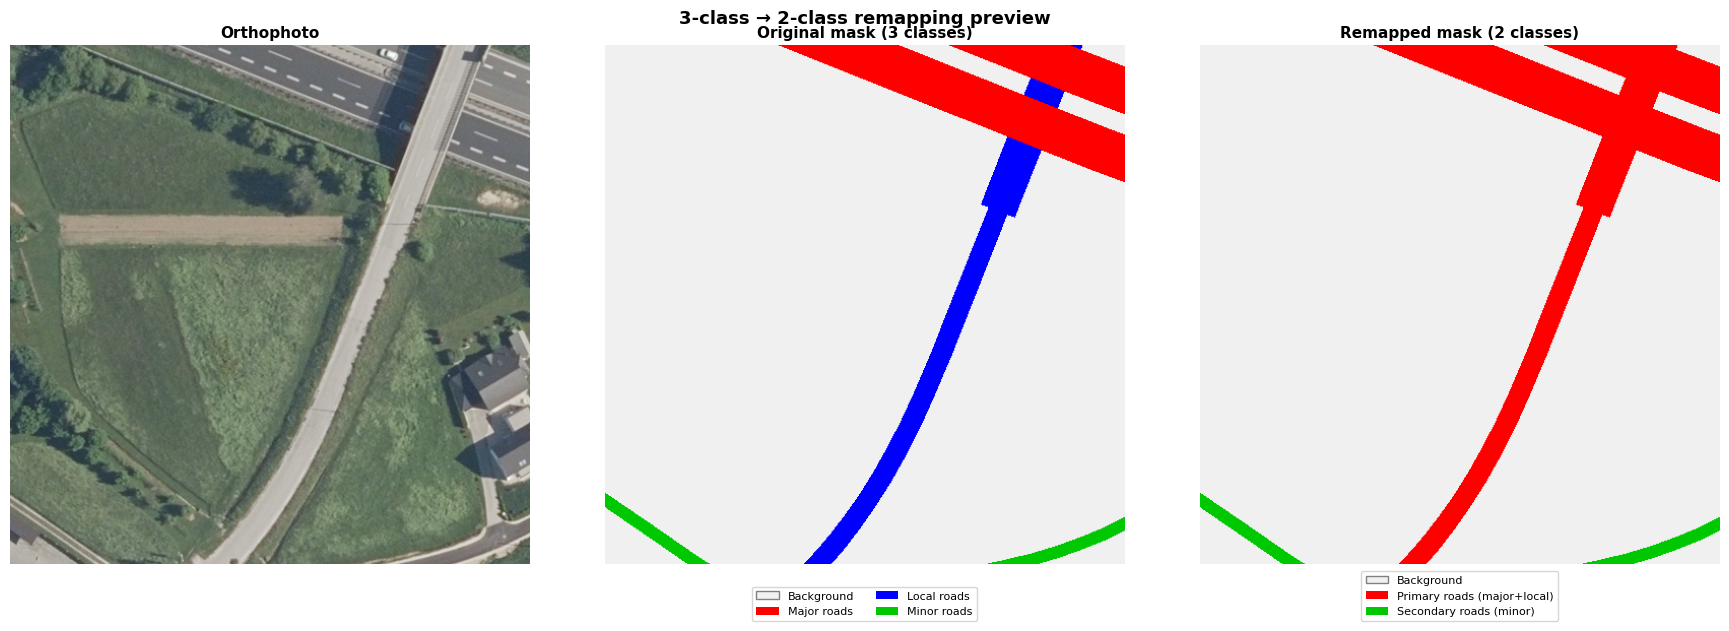


=== Pixel count verification ===
Old mask unique values: [0 1 2 3]
New mask unique values: [0 1 2]

Old class 1 pixels: 19,021
Old class 2 pixels: 11,138
New class 1 pixels: 30,159 (should be 30,159)
Old class 3 pixels: 2,754
New class 2 pixels: 2,754 (should be 2,754)


In [2]:
# Cell 2 — Visualize remapping logic on one sample tile

# Remap function
# Old: 0=background, 1=major, 2=local, 3=minor
# New: 0=background, 1=primary (old 1+2), 2=secondary (old 3)
def remap_mask(mask):
    new_mask = np.zeros_like(mask)
    new_mask[mask == 1] = 1  # major → primary
    new_mask[mask == 2] = 1  # local → primary
    new_mask[mask == 3] = 2  # minor → secondary
    return new_mask

def mask_to_rgb_3class(mask):
    rgb = np.zeros((*mask.shape, 3), dtype=np.uint8)
    rgb[mask == 0] = [240, 240, 240]
    rgb[mask == 1] = [255, 0,   0]
    rgb[mask == 2] = [0,   0,   255]
    rgb[mask == 3] = [0,   200, 0]
    return rgb

def mask_to_rgb_2class(mask):
    rgb = np.zeros((*mask.shape, 3), dtype=np.uint8)
    rgb[mask == 0] = [240, 240, 240]
    rgb[mask == 1] = [255, 0,   0]    # primary - red
    rgb[mask == 2] = [0,   200, 0]    # secondary - green
    return rgb

# Find a good tile with all 3 road classes present
sample = tile_df[
    (tile_df['class_1_ratio'] > 0.005) &
    (tile_df['class_2_ratio'] > 0.005) &
    (tile_df['class_3_ratio'] > 0.005)
].iloc[0]

print(f"Sample tile: {sample['tile_id']}")
print(f"Municipality: {sample['municipality']}")
print(f"Class ratios — Major: {sample['class_1_ratio']:.4f} | "
      f"Local: {sample['class_2_ratio']:.4f} | "
      f"Minor: {sample['class_3_ratio']:.4f}")

# Load and remap
img      = np.load(sample['image_path'])
mask_old = np.load(sample['mask_path'])
mask_new = remap_mask(mask_old)

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(img)
axes[0].set_title('Orthophoto', fontsize=11, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(mask_to_rgb_3class(mask_old))
axes[1].set_title('Original mask (3 classes)', fontsize=11, fontweight='bold')
axes[1].axis('off')

axes[2].imshow(mask_to_rgb_2class(mask_new))
axes[2].set_title('Remapped mask (2 classes)', fontsize=11, fontweight='bold')
axes[2].axis('off')

from matplotlib.patches import Patch
legend_3 = [
    Patch(facecolor='#F0F0F0', edgecolor='grey', label='Background'),
    Patch(facecolor='#FF0000', label='Major roads'),
    Patch(facecolor='#0000FF', label='Local roads'),
    Patch(facecolor='#00C800', label='Minor roads')
]
legend_2 = [
    Patch(facecolor='#F0F0F0', edgecolor='grey', label='Background'),
    Patch(facecolor='#FF0000', label='Primary roads (major+local)'),
    Patch(facecolor='#00C800', label='Secondary roads (minor)')
]

axes[1].legend(handles=legend_3, loc='lower center',
               bbox_to_anchor=(0.5, -0.12), ncol=2, fontsize=8)
axes[2].legend(handles=legend_2, loc='lower center',
               bbox_to_anchor=(0.5, -0.12), ncol=1, fontsize=8)

plt.suptitle('3-class → 2-class remapping preview',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('remap_preview.png', dpi=150, bbox_inches='tight')
plt.show()

# Verify pixel counts
print(f"\n=== Pixel count verification ===")
print(f"Old mask unique values: {np.unique(mask_old)}")
print(f"New mask unique values: {np.unique(mask_new)}")
print(f"\nOld class 1 pixels: {(mask_old==1).sum():,}")
print(f"Old class 2 pixels: {(mask_old==2).sum():,}")
print(f"New class 1 pixels: {(mask_new==1).sum():,} "
      f"(should be {(mask_old==1).sum() + (mask_old==2).sum():,})")
print(f"Old class 3 pixels: {(mask_old==3).sum():,}")
print(f"New class 2 pixels: {(mask_new==2).sum():,} "
      f"(should be {(mask_old==3).sum():,})")

In [4]:
import time
import numpy as np
from pathlib import Path

# Test speed on 10 tiles
sample_tiles = tile_df[tile_df['road_pixel_ratio'] > 0].head(10)

t = time.time()
for _, row in sample_tiles.iterrows():
    mask = np.load(row['mask_path'])
    new_mask = remap_mask(mask)
    out_path = NEW_MASKS_DIR / row['split'] / Path(row['mask_path']).name
    np.save(out_path, new_mask)

elapsed = time.time() - t
rate    = 10 / elapsed
total_estimate = len(tile_df) / rate / 60

print(f"10 tiles in {elapsed:.2f}s")
print(f"Speed: {rate:.1f} tiles/s")
print(f"Estimated total time: {total_estimate:.1f} min")

10 tiles in 0.06s
Speed: 174.3 tiles/s
Estimated total time: 25.0 min


In [5]:
# Cell 3 — Apply remapping to all tiles

print("Starting remapping of all tiles...")
print("Progress every 5,000 tiles\n")

records   = []
errors    = []
processed = 0
skipped   = 0
t_start   = time.time()

for idx, row in tile_df.iterrows():
    try:
        split         = row['split']
        mask_path     = Path(row['mask_path'])
        new_mask_path = NEW_MASKS_DIR / split / mask_path.name

        # Load and remap
        if new_mask_path.exists():
            skipped += 1
            new_mask = np.load(new_mask_path)
        else:
            mask_old = np.load(mask_path)
            new_mask = remap_mask(mask_old)
            np.save(new_mask_path, new_mask)
            processed += 1

        # Calculate ratios
        total_px  = new_mask.size
        bg        = (new_mask == 0).sum() / total_px
        primary   = (new_mask == 1).sum() / total_px
        secondary = (new_mask == 2).sum() / total_px

        records.append({
            'tile_id':          row['tile_id'],
            'image_path':       row['image_path'],
            'mask_path':        str(new_mask_path),
            'source_ortho':     row['source_ortho'],
            'municipality':     row['municipality'],
            'split':            split,
            'landscape_type':   row['landscape_type'],
            'road_pixel_ratio': round(primary + secondary, 4),
            'class_1_ratio':    round(primary,             4),
            'class_2_ratio':    round(secondary,           4),
            'background_ratio': round(bg,                  4),
            'y_offset':         row['y_offset'],
            'x_offset':         row['x_offset']
        })

        total_done = processed + skipped
        if total_done % 5000 == 0:
            elapsed = time.time() - t_start
            rate    = total_done / elapsed
            remain  = (len(tile_df) - total_done) / rate / 60
            print(f"  {total_done:,}/{len(tile_df):,} | "
                  f"{rate:.0f} tiles/s | "
                  f"~{remain:.1f} min remaining", flush=True)

    except Exception as e:
        errors.append({'tile_id': row['tile_id'], 'error': str(e)})

elapsed_total = time.time() - t_start
print(f"\n=== Remapping complete ===")
print(f"Processed: {processed:,}")
print(f"Skipped:   {skipped:,}")
print(f"Errors:    {len(errors)}")
print(f"Time:      {elapsed_total/60:.1f} min")

Starting remapping of all tiles...
Progress every 5,000 tiles

  5,000/261,234 | 49 tiles/s | ~87.0 min remaining
  10,000/261,234 | 49 tiles/s | ~84.9 min remaining
  15,000/261,234 | 47 tiles/s | ~86.8 min remaining
  20,000/261,234 | 45 tiles/s | ~89.4 min remaining
  25,000/261,234 | 44 tiles/s | ~90.0 min remaining
  30,000/261,234 | 43 tiles/s | ~89.8 min remaining
  35,000/261,234 | 42 tiles/s | ~89.2 min remaining
  40,000/261,234 | 42 tiles/s | ~88.2 min remaining
  45,000/261,234 | 41 tiles/s | ~86.9 min remaining
  50,000/261,234 | 41 tiles/s | ~85.4 min remaining
  55,000/261,234 | 41 tiles/s | ~83.9 min remaining
  60,000/261,234 | 41 tiles/s | ~82.2 min remaining
  65,000/261,234 | 41 tiles/s | ~80.5 min remaining
  70,000/261,234 | 41 tiles/s | ~78.7 min remaining
  75,000/261,234 | 40 tiles/s | ~76.8 min remaining
  80,000/261,234 | 40 tiles/s | ~75.0 min remaining
  85,000/261,234 | 40 tiles/s | ~73.1 min remaining
  90,000/261,234 | 40 tiles/s | ~71.2 min remaining
  

In [6]:
# Cell 4 — Save new tile index and verify

new_index = pd.DataFrame(records)

# Save
new_index_path = META_DIR / 'tile_index_2class.csv'
new_index.to_csv(new_index_path, index=False)

print(f"=== New tile index saved ===")
print(f"Path: {new_index_path}")
print(f"Total tiles: {len(new_index):,}")

print(f"\n=== Split distribution ===")
print(new_index['split'].value_counts().to_string())

print(f"\n=== New class distribution (mean ratios) ===")
print(f"Background:       {new_index['background_ratio'].mean():.4f}")
print(f"Primary roads:    {new_index['class_1_ratio'].mean():.4f}")
print(f"Secondary roads:  {new_index['class_2_ratio'].mean():.4f}")

print(f"\n=== Comparison with 3-class ===")
print(f"Old Class 1+2 combined: "
      f"{tile_df['class_1_ratio'].mean() + tile_df['class_2_ratio'].mean():.4f}")
print(f"New Class 1 (primary):  {new_index['class_1_ratio'].mean():.4f}")
print(f"Old Class 3:            {tile_df['class_3_ratio'].mean():.4f}")
print(f"New Class 2 (secondary):{new_index['class_2_ratio'].mean():.4f}")

print(f"\n=== Verification — ratios should match ===")
old_combined = tile_df['class_1_ratio'].mean() + tile_df['class_2_ratio'].mean()
new_primary  = new_index['class_1_ratio'].mean()
match = abs(old_combined - new_primary) < 0.0001
print(f"Primary match: {'✅' if match else '❌'} "
      f"(diff={abs(old_combined-new_primary):.6f})")

=== New tile index saved ===
Path: D:\lstojano\road_extraction_slovenia\data\processed\metadata\tile_index_2class.csv
Total tiles: 261,234

=== Split distribution ===
split
train    173224
test      45776
val       42234

=== New class distribution (mean ratios) ===
Background:       0.9613
Primary roads:    0.0113
Secondary roads:  0.0274

=== Comparison with 3-class ===
Old Class 1+2 combined: 0.0113
New Class 1 (primary):  0.0113
Old Class 3:            0.0274
New Class 2 (secondary):0.0274

=== Verification — ratios should match ===
Primary match: ✅ (diff=0.000000)


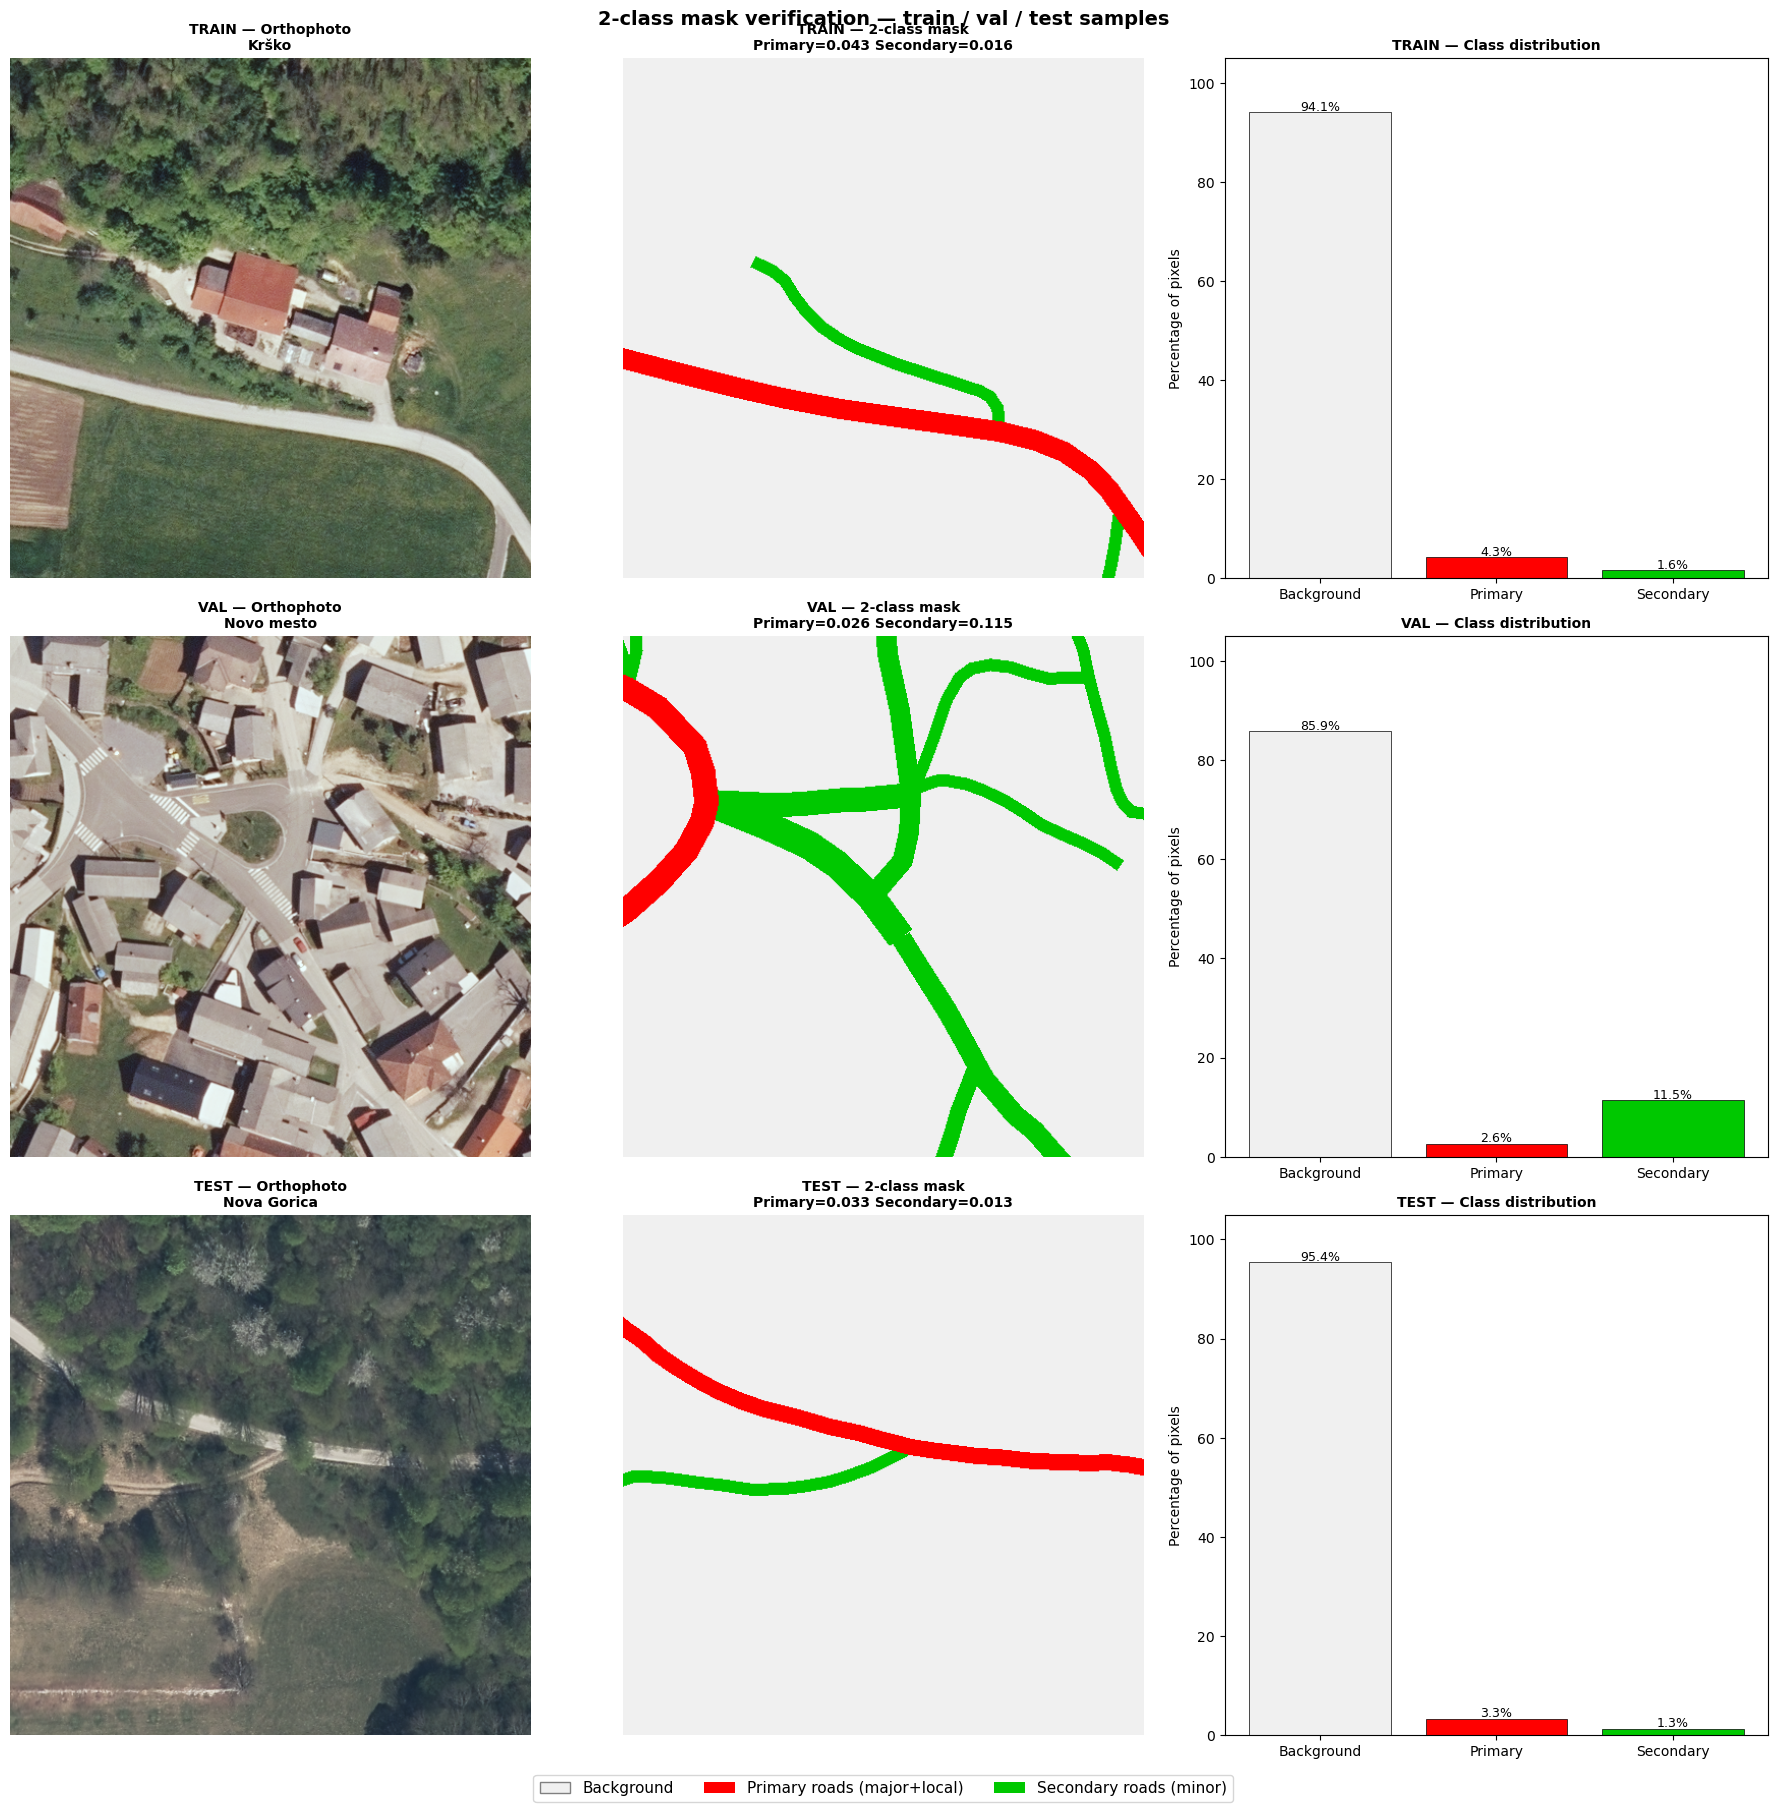

Notebook complete — ready for training.

New tile index: D:\lstojano\road_extraction_slovenia\data\processed\metadata\tile_index_2class.csv
New masks dir:  D:\lstojano\road_extraction_slovenia\data\processed\masks_2class


In [7]:
# Cell 5 — Final visual verification on samples from each split

fig, axes = plt.subplots(3, 3, figsize=(18, 18))

splits = ['train', 'val', 'test']

for row_idx, split in enumerate(splits):
    # Pick tile with both primary and secondary roads
    split_tiles = new_index[
        (new_index['split'] == split) &
        (new_index['class_1_ratio'] > 0.01) &
        (new_index['class_2_ratio'] > 0.01)
    ]

    if len(split_tiles) == 0:
        split_tiles = new_index[
            (new_index['split'] == split) &
            (new_index['road_pixel_ratio'] > 0.02)
        ]

    sample = split_tiles.iloc[0]

    img      = np.load(sample['image_path'])
    mask_new = np.load(sample['mask_path'])

    # Orthophoto
    axes[row_idx, 0].imshow(img)
    axes[row_idx, 0].set_title(f'{split.upper()} — Orthophoto\n'
                                f"{sample['municipality']}",
                                fontsize=10, fontweight='bold')
    axes[row_idx, 0].axis('off')

    # New 2-class mask
    axes[row_idx, 1].imshow(mask_to_rgb_2class(mask_new))
    axes[row_idx, 1].set_title(f'{split.upper()} — 2-class mask\n'
                                f"Primary={sample['class_1_ratio']:.3f} "
                                f"Secondary={sample['class_2_ratio']:.3f}",
                                fontsize=10, fontweight='bold')
    axes[row_idx, 1].axis('off')

    # Histogram of class distribution
    unique, counts = np.unique(mask_new, return_counts=True)
    class_names    = {0: 'Background', 1: 'Primary', 2: 'Secondary'}
    colors         = ['#F0F0F0', '#FF0000', '#00C800']
    bar_colors     = [colors[u] for u in unique]
    bar_labels     = [class_names[u] for u in unique]
    pcts           = counts / counts.sum() * 100

    bars = axes[row_idx, 2].bar(bar_labels, pcts,
                                 color=bar_colors,
                                 edgecolor='black', linewidth=0.5)
    for bar, pct in zip(bars, pcts):
        axes[row_idx, 2].text(bar.get_x() + bar.get_width()/2,
                               bar.get_height() + 0.3,
                               f'{pct:.1f}%',
                               ha='center', fontsize=9)
    axes[row_idx, 2].set_title(f'{split.upper()} — Class distribution',
                                fontsize=10, fontweight='bold')
    axes[row_idx, 2].set_ylabel('Percentage of pixels')
    axes[row_idx, 2].set_ylim(0, 105)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#F0F0F0', edgecolor='grey', label='Background'),
    Patch(facecolor='#FF0000', label='Primary roads (major+local)'),
    Patch(facecolor='#00C800', label='Secondary roads (minor)')
]
fig.legend(handles=legend_elements, loc='lower center',
           ncol=3, fontsize=11, bbox_to_anchor=(0.5, -0.02))

plt.suptitle('2-class mask verification — train / val / test samples',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('2class_verification.png', dpi=150, bbox_inches='tight')
plt.show()

print("Notebook complete — ready for training.")
print(f"\nNew tile index: {new_index_path}")
print(f"New masks dir:  {NEW_MASKS_DIR}")